# The Fenty Effect — Final Analysis Notebook
### COGS 109 Final Project

End-to-end analysis for the paper. Runs in order; every numbered section produces results or figures that map directly to a section of the writeup.

**Outcomes analyzed:**
- Primary: `shade_count` per product line (M1–M4)
- Secondary: `lightness_var` per product line (L1–L3), tests segmentation hypothesis

**Model classes:** linear regression, LASSO, segmented (piecewise) regression — all course methods.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

SEED = 42
K = 5  # number of CV folds

## 2. Data loading and product-line aggregation

Load the filtered shade-level dataset, aggregate to product-line level (one row per `product_line × brand`). Use `min(release_year)` for the release date (closest available proxy for launch). Drop rows missing year or brand.

In [42]:
# Load shade-level data
df = pd.read_csv('data/02-processed/merged_full_RELEASE_DATES_FILTERED.csv')
df['release_year'] = pd.to_datetime(df['approx_release_date_dt']).dt.year
df = df.rename(columns={'brand_all': 'brand', 'product_all': 'product_line'})
df = df.dropna(subset=['release_year', 'brand'])

# Aggregate to product-line level
product_level = (
    df.groupby(['product_line', 'brand'])
    .agg(
        release_year=('release_year', 'min'),
        shade_count=('hex', 'nunique'),
        lightness_var=('lightness', 'var'),
    )
    .reset_index()
)

n = len(product_level)
n_brands = product_level['brand'].nunique()
print(f'n product lines:      {n}')
print(f'unique brands:        {n_brands} -> {n_brands - 1} dummies w/ drop_first')
print(f'release year range:   {int(product_level["release_year"].min())} - {int(product_level["release_year"].max())}')
print(f'shade_count range:    {product_level["shade_count"].min()} - {product_level["shade_count"].max()} (median {product_level["shade_count"].median():.0f})')
print(f'pre-2017 lines:       {(product_level["release_year"] < 2017).sum()}')
print(f'2017+ lines:          {(product_level["release_year"] >= 2017).sum()}')
product_level.head()

n product lines:      314
unique brands:        104 -> 103 dummies w/ drop_first
release year range:   2016 - 2025
shade_count range:    1 - 60 (median 16)
pre-2017 lines:       3
2017+ lines:          311


,product_line,brand,release_year,shade_count,lightness_var
0,"""Un"" Cover-Up Cream Foundation",rms beauty,2021,14,0.025872
1,"""Un"" Cover-up Concealer",rms beauty,2020,16,0.020684
2,#FauxFilter Full Coverage Matte Foundation,HUDA BEAUTY,2020,29,0.026046
3,#FauxFilter Skin Finish Buildable Coverage Fou...,HUDA BEAUTY,2024,35,0.023855
4,10 Hour Wear Perfection Foundation,SEPHORA COLLECTION,2017,51,0.012950


## 3. Cross-validation setup

5-fold CV at the product-line level. Helper returns both training RMSE (model refit on the full data) and the mean CV RMSE across folds. The gap between them is our overfitting diagnostic.

In [43]:
kf = KFold(n_splits=K, shuffle=True, random_state=SEED)

def evaluate_model(model, X, y, kf):
    cv_rmses = []
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model.fit(X_train, y_train)
        cv_rmses.append(np.sqrt(mean_squared_error(y_test, model.predict(X_test))))
    # full-data training RMSE for the overfitting gap
    model.fit(X, y)
    train_rmse = np.sqrt(mean_squared_error(y, model.predict(X)))
    return train_rmse, np.mean(cv_rmses)

# Initialize separate results dicts for the two outcomes
results_sc = {}  # shade count
results_lv = {}  # lightness variance

## 4. Shade-count models (primary outcome)

Four model specifications of increasing flexibility and structure:

- **M1** `shade_count ~ year` — floor; tests whether year alone has signal
- **M2** `shade_count ~ year + brand` — adds 103 brand dummies; expected to overfit
- **M3** LASSO on M2's predictors — regularization handles brand sparsity
- **M4** segmented year + brand — tests Fenty as a structural break at 2017

All four use the same 5-fold CV split for apples-to-apples comparison.

### M1: `shade_count ~ year`

In [44]:
X_M1 = product_level[['release_year']].values
y_sc = product_level['shade_count'].values

m1_sc = LinearRegression()
train_rmse, cv_rmse = evaluate_model(m1_sc, X_M1, y_sc, kf)
results_sc['M1'] = {'n_params': 1, 'train_rmse': train_rmse, 'cv_rmse': cv_rmse}

print(f'year coefficient: {m1_sc.coef_[0]:.4f} shades/year')
print(f'intercept:        {m1_sc.intercept_:.4f}')
print(f'train RMSE:       {train_rmse:.4f}')
print(f'CV RMSE:          {cv_rmse:.4f}')
print(f'train/CV gap:     {cv_rmse - train_rmse:.4f}')

year coefficient: -1.3998 shades/year
intercept:        2846.6216
train RMSE:       13.0298
CV RMSE:          13.0757
train/CV gap:     0.0459


### M2: `shade_count ~ year + brand` (all 103 brand dummies — overfitting demo)

In [45]:
# year + brand dummies (drop_first=True to avoid perfect collinearity with intercept)
X_M2 = pd.concat([
    product_level[['release_year']],
    pd.get_dummies(product_level['brand'], drop_first=True)
], axis=1).values.astype(float)

m2_sc = LinearRegression()
train_rmse, cv_rmse = evaluate_model(m2_sc, X_M2, y_sc, kf)
results_sc['M2'] = {'n_params': X_M2.shape[1], 'train_rmse': train_rmse, 'cv_rmse': cv_rmse}

year_coef_M2 = m2_sc.coef_[0]  # year is column 0
print(f'n features (year + brand dummies): {X_M2.shape[1]}')
print(f'year coefficient (brand-adjusted): {year_coef_M2:.4f} shades/year')
print(f'train RMSE:   {train_rmse:.4f}')
print(f'CV RMSE:      {cv_rmse:.4f}')
print(f'train/CV gap: {cv_rmse - train_rmse:.4f}  <-- overfitting signature')

n features (year + brand dummies): 104
year coefficient (brand-adjusted): -1.1435 shades/year
train RMSE:   9.4192
CV RMSE:      14.3778
train/CV gap: 4.9586  <-- overfitting signature


### M3: LASSO on year + brand (λ chosen by inner CV)

In [46]:
m3_sc = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=K, random_state=SEED, alphas=200, max_iter=20000))
])

train_rmse, cv_rmse = evaluate_model(m3_sc, X_M2, y_sc, kf)

# Pull coefficients explicitly from m3_sc so nothing shadows them
lasso_m3 = m3_sc.named_steps['lasso']
coef_m3 = lasso_m3.coef_
alpha_m3 = lasso_m3.alpha_
nonzero_mask = np.abs(coef_m3) > 1e-8
n_nonzero = int(nonzero_mask.sum())

results_sc['M3'] = {'n_params': n_nonzero, 'train_rmse': train_rmse, 'cv_rmse': cv_rmse}

print(f'selected lambda (alpha):      {alpha_m3:.4f}')
print(f'alpha search range:           {lasso_m3.alphas_.min():.4f} - {lasso_m3.alphas_.max():.4f}')
print(f'non-zero coefs (year+brands): {n_nonzero} of {len(coef_m3)}')
print(f'year coefficient (scaled):    {coef_m3[0]:.4f}')
print(f'train RMSE:                   {train_rmse:.4f}')
print(f'CV RMSE:                      {cv_rmse:.4f}')
print(f'train/CV gap:                 {cv_rmse - train_rmse:.4f}')

selected lambda (alpha):      1.1641
alpha search range:           0.0029 - 2.8705
non-zero coefs (year+brands): 22 of 104
year coefficient (scaled):    -1.2377
train RMSE:                   12.2285
CV RMSE:                      13.0011
train/CV gap:                 0.7727


### M4: Segmented (piecewise) year + brand — explicit Fenty-break test

Three year-related terms:
- `release_year` — overall linear trend
- `post_2017` — level shift at 2017 (the Fenty bump)
- `year_since_2017` — slope change after 2017

Coefficient interpretations:
- `post_2017` > 0 means shade counts jumped upward at 2017
- `year_since_2017` > 0 means the trend accelerated post-Fenty

In [47]:
year = product_level['release_year'].values
post_2017 = (year >= 2017).astype(float)
year_since_2017 = post_2017 * (year - 2017)

brand_dummies = pd.get_dummies(product_level['brand'], drop_first=True).values.astype(float)
X_M4 = np.column_stack([year, post_2017, year_since_2017, brand_dummies])

# Use LASSO (matches M3's regularization approach so the comparison isolates segmentation)
m4_sc = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=K, random_state=SEED, alphas=200, max_iter=20000))
])

train_rmse, cv_rmse = evaluate_model(m4_sc, X_M4, y_sc, kf)

lasso_m4 = m4_sc.named_steps['lasso']
coef_m4 = lasso_m4.coef_
alpha_m4 = lasso_m4.alpha_
n_nonzero_m4 = int(np.sum(np.abs(coef_m4) > 1e-8))

results_sc['M4'] = {'n_params': n_nonzero_m4, 'train_rmse': train_rmse, 'cv_rmse': cv_rmse}

# Read off the three segmented-year terms (columns 0, 1, 2)
# These are on the standardized scale
print(f'selected lambda:                       {alpha_m4:.4f}')
print(f'non-zero coefs (year3+brands):         {n_nonzero_m4} of {len(coef_m4)}')
print(f'year coefficient (scaled):             {coef_m4[0]:.4f}')
print(f'post-2017 level shift (scaled):        {coef_m4[1]:.4f}')
print(f'post-2017 slope change (scaled):       {coef_m4[2]:.4f}')
print(f'train RMSE:                            {train_rmse:.4f}')
print(f'CV RMSE:                               {cv_rmse:.4f}')

selected lambda:                       1.1641
non-zero coefs (year3+brands):         22 of 106
year coefficient (scaled):             -0.0000
post-2017 level shift (scaled):        -0.0000
post-2017 slope change (scaled):       -1.2419
train RMSE:                            12.2279
CV RMSE:                               13.0005


### Shade-count model comparison

In [48]:
comparison_sc = (
    pd.DataFrame(results_sc).T
    .reset_index().rename(columns={'index': 'model'})
)
comparison_sc['gap'] = comparison_sc['cv_rmse'] - comparison_sc['train_rmse']
comparison_sc = comparison_sc.sort_values('cv_rmse').reset_index(drop=True)

best_sc = comparison_sc.loc[0, 'model']
print('SHADE COUNT — model comparison (lower CV RMSE is better):')
print(comparison_sc.to_string(index=False))
print(f'\nselected model: {best_sc}')

SHADE COUNT — model comparison (lower CV RMSE is better):
model  n_params  train_rmse   cv_rmse      gap
   M4      22.0   12.227911 13.000499 0.772588
   M3      22.0   12.228454 13.001139 0.772685
   M1       1.0   13.029828 13.075696 0.045868
   M2     104.0    9.419211 14.377777 4.958565

selected model: M4


## 5. Lightness-variance models (secondary outcome — segmentation test)

The segmentation hypothesis predicts that newer product lines target narrower tonal ranges — so `lightness_var` should decline with release year. We mirror the M1/M2/M3 structure with `lightness_var` as the outcome, after dropping single-shade lines (which have undefined within-line variance).

In [49]:
# Drop single-shade lines (lightness_var is NaN or 0 for them)
mask_lv = product_level['lightness_var'].notna() & (product_level['lightness_var'] > 0)
prod_lv = product_level[mask_lv].copy()

y_lv = prod_lv['lightness_var'].values
n_lv = len(prod_lv)

print(f'lightness analysis sample: {n_lv} product lines ({len(product_level) - n_lv} dropped)')
print(f'lightness_var range:       {y_lv.min():.4f} - {y_lv.max():.4f}')
print(f'lightness_var median:      {np.median(y_lv):.4f}')

lightness analysis sample: 303 product lines (11 dropped)
lightness_var range:       0.0000 - 0.1260
lightness_var median:      0.0181


### L1: `lightness_var ~ year`

In [50]:
X_L1 = prod_lv[['release_year']].values

l1 = LinearRegression()
train_rmse, cv_rmse = evaluate_model(l1, X_L1, y_lv, kf)
results_lv['L1'] = {'n_params': 1, 'train_rmse': train_rmse, 'cv_rmse': cv_rmse}

print(f'year coefficient on lightness_var: {l1.coef_[0]:.6f}')
print(f'intercept: {l1.intercept_:.4f}')
print(f'train RMSE: {train_rmse:.6f}')
print(f'CV RMSE:    {cv_rmse:.6f}')
print('\nInterpretation:')
print('  negative + meaningful magnitude -> supports segmentation hypothesis')
print('  ~zero magnitude or CV <= train  -> rules out segmentation')

year coefficient on lightness_var: -0.000764
intercept: 1.5620
train RMSE: 0.013080
CV RMSE:    0.012909

Interpretation:
  negative + meaningful magnitude -> supports segmentation hypothesis
  ~zero magnitude or CV <= train  -> rules out segmentation


### L2: `lightness_var ~ year + brand`

In [51]:
X_L2 = pd.concat([
    prod_lv[['release_year']],
    pd.get_dummies(prod_lv['brand'], drop_first=True)
], axis=1).values.astype(float)

l2 = LinearRegression()
train_rmse, cv_rmse = evaluate_model(l2, X_L2, y_lv, kf)
results_lv['L2'] = {'n_params': X_L2.shape[1], 'train_rmse': train_rmse, 'cv_rmse': cv_rmse}

print(f'brand-adjusted year coefficient: {l2.coef_[0]:.6f}')
print(f'n features (year + brand): {X_L2.shape[1]}')
print(f'train RMSE: {train_rmse:.6f}')
print(f'CV RMSE:    {cv_rmse:.6f}')
print(f'gap:        {cv_rmse - train_rmse:.6f}')

brand-adjusted year coefficient: -0.000887
n features (year + brand): 103
train RMSE: 0.009023
CV RMSE:    0.015081
gap:        0.006058


### L3: LASSO on year + brand for lightness_var

In [52]:
l3 = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=K, random_state=SEED, alphas=200, max_iter=20000))
])

train_rmse, cv_rmse = evaluate_model(l3, X_L2, y_lv, kf)

lasso_l3 = l3.named_steps['lasso']
coef_l3 = lasso_l3.coef_
alpha_l3 = lasso_l3.alpha_
n_nonzero_l3 = int(np.sum(np.abs(coef_l3) > 1e-8))

results_lv['L3'] = {'n_params': n_nonzero_l3, 'train_rmse': train_rmse, 'cv_rmse': cv_rmse}

print(f'selected lambda: {alpha_l3:.4f}')
print(f'non-zero coefs: {n_nonzero_l3} of {len(coef_l3)}')
print(f'year coefficient (scaled): {coef_l3[0]:.6f}')
print(f'train RMSE: {train_rmse:.6f}')
print(f'CV RMSE:    {cv_rmse:.6f}')

selected lambda: 0.0005
non-zero coefs: 58 of 103
year coefficient (scaled): -0.000896
train RMSE: 0.010015
CV RMSE:    0.012807


### Lightness-variance model comparison

In [53]:
comparison_lv = (
    pd.DataFrame(results_lv).T
    .reset_index().rename(columns={'index': 'model'})
)
comparison_lv['gap'] = comparison_lv['cv_rmse'] - comparison_lv['train_rmse']
comparison_lv = comparison_lv.sort_values('cv_rmse').reset_index(drop=True)

print('LIGHTNESS VARIANCE — model comparison:')
print(comparison_lv.to_string(index=False))
print(f'\nselected model: {comparison_lv.loc[0, "model"]}')

# Test the segmentation hypothesis explicitly
best_year_coef_lv = l1.coef_[0]  # use the unadjusted version for clean interpretation
print(f'\nSegmentation hypothesis test:')
print(f'  year coefficient on within-line lightness variance: {best_year_coef_lv:.6f}')
if abs(best_year_coef_lv) < 0.001 or comparison_lv.iloc[0]['cv_rmse'] <= comparison_lv.iloc[0]['train_rmse'] + 0.0001:
    print('  -> Segmentation hypothesis NOT supported by the data.')
    print('     Within-line lightness variance is approximately constant over time.')
else:
    print('  -> Segmentation hypothesis is consistent with the data.')

LIGHTNESS VARIANCE — model comparison:
model  n_params  train_rmse  cv_rmse       gap
   L3      58.0    0.010015 0.012807  0.002792
   L1       1.0    0.013080 0.012909 -0.000171
   L2     103.0    0.009023 0.015081  0.006058

selected model: L3

Segmentation hypothesis test:
  year coefficient on within-line lightness variance: -0.000764
  -> Segmentation hypothesis NOT supported by the data.
     Within-line lightness variance is approximately constant over time.


## 6. Figures for the paper

Five figures, each one rubric-worthy and each one tells a different piece of the story.


### Figure 1: Shade-count distribution by release year

/var/folders/85/44fkb77531sd5mlxlbnc5bxc0000gn/T/ipykernel_47853/205182140.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_year, labels=[int(y) for y in years_sorted], showfliers=False)


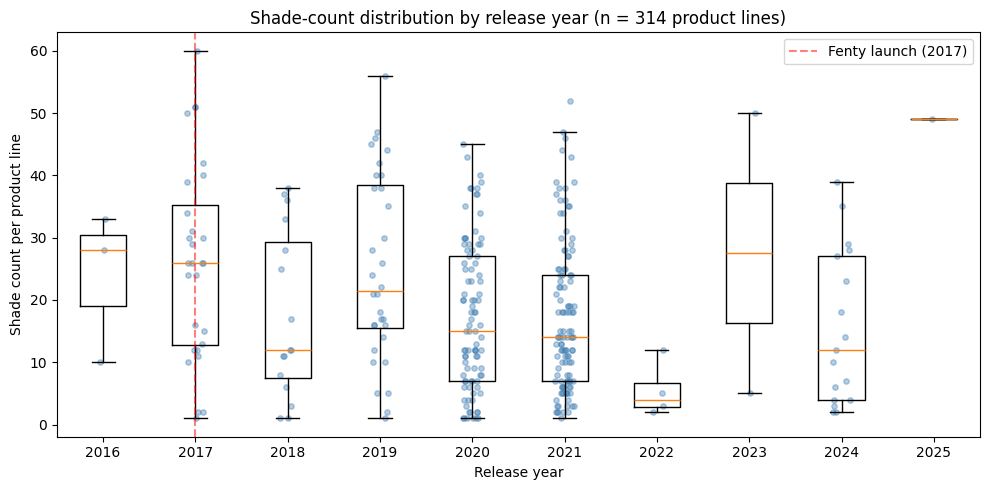

In [54]:
fig, ax = plt.subplots(figsize=(10, 5))
years_sorted = sorted(product_level['release_year'].unique())
data_by_year = [product_level[product_level['release_year'] == y]['shade_count'].values
                for y in years_sorted]
ax.boxplot(data_by_year, labels=[int(y) for y in years_sorted], showfliers=False)
for i, vals in enumerate(data_by_year):
    ax.scatter(np.full_like(vals, i + 1, dtype=float) + np.random.uniform(-0.1, 0.1, size=len(vals)),
               vals, alpha=0.4, s=15, color='steelblue')
ax.axvline(x=[i+1 for i, y in enumerate(years_sorted) if y == 2017][0] if 2017 in years_sorted else None,
           color='red', linestyle='--', alpha=0.5, label='Fenty launch (2017)')
ax.set_xlabel('Release year')
ax.set_ylabel('Shade count per product line')
ax.set_title(f'Shade-count distribution by release year (n = {n} product lines)')
if 2017 in years_sorted:
    ax.legend()
plt.tight_layout(); plt.show()

### Figure 2: Model comparison — training vs CV RMSE with overfitting gaps

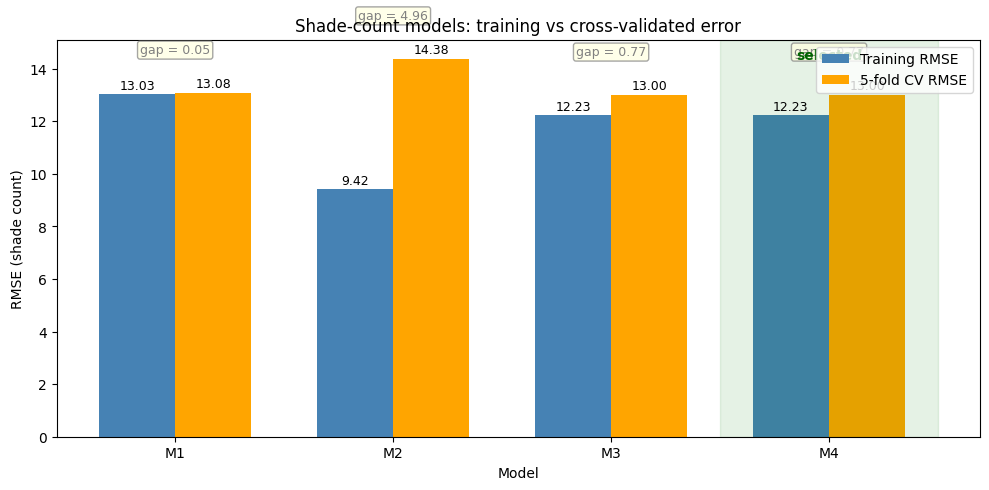

In [55]:
plot_sc = pd.DataFrame(results_sc).T.loc[['M1', 'M2', 'M3', 'M4']]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_sc)); width = 0.35
bars_train = ax.bar(x - width/2, plot_sc['train_rmse'], width, label='Training RMSE', color='steelblue')
bars_cv = ax.bar(x + width/2, plot_sc['cv_rmse'], width, label='5-fold CV RMSE', color='orange')

for b in list(bars_train) + list(bars_cv):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
            f'{b.get_height():.2f}', ha='center', fontsize=9)

for i, (tr, cv) in enumerate(zip(plot_sc['train_rmse'], plot_sc['cv_rmse'])):
    ax.text(i, max(tr, cv) + 1.5, f'gap = {cv - tr:.2f}',
            ha='center', fontsize=9, color='gray',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', edgecolor='gray', alpha=0.7))

# Highlight selected model
best_idx = list(plot_sc.index).index(best_sc)
ax.axvspan(best_idx - 0.5, best_idx + 0.5, color='green', alpha=0.1)
ax.text(best_idx, ax.get_ylim()[1] * 0.95, 'selected', ha='center',
        fontsize=10, color='darkgreen', fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(plot_sc.index)
ax.set_xlabel('Model'); ax.set_ylabel('RMSE (shade count)')
ax.set_title('Shade-count models: training vs cross-validated error')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

### Figure 3: LASSO surviving brand coefficients (M3)

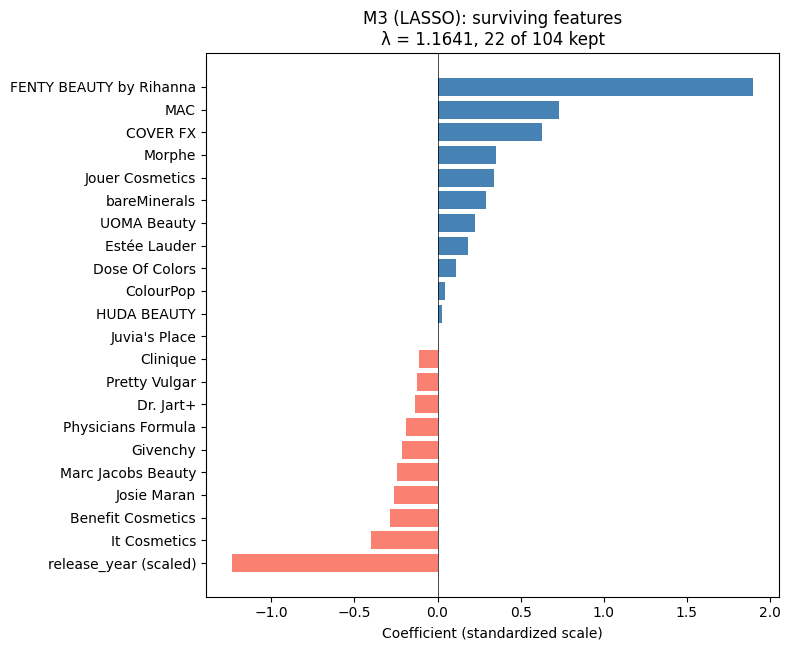


year coefficient: -1.2377 (standardized)
  -> direction: negative
  -> hypothesis test: H0 (no trend) rejected by sign


In [56]:
brand_dummy_names = list(pd.get_dummies(product_level['brand'], drop_first=True).columns)
feat_names_m3 = ['release_year (scaled)'] + brand_dummy_names

assert len(feat_names_m3) == len(coef_m3)

nonzero = pd.DataFrame({
    'feature': np.array(feat_names_m3)[nonzero_mask],
    'coef': coef_m3[nonzero_mask]
}).sort_values('coef')

fig, ax = plt.subplots(figsize=(8, max(5, len(nonzero) * 0.3)))
colors = ['steelblue' if c > 0 else 'salmon' for c in nonzero['coef']]
ax.barh(nonzero['feature'], nonzero['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (standardized scale)')
ax.set_title(f'M3 (LASSO): surviving features\nλ = {alpha_m3:.4f}, {n_nonzero} of {len(coef_m3)} kept')
plt.tight_layout(); plt.show()

# Also print the year coefficient interpretation
print(f'\nyear coefficient: {coef_m3[0]:.4f} (standardized)')
print(f'  -> direction: {"positive" if coef_m3[0] > 0 else "negative"}')
print(f'  -> hypothesis test: H0 (no trend) {"rejected by sign" if coef_m3[0] < 0 else "supported in direction"}')

### Figure 4: LASSO regularization path (where the optimum sits)

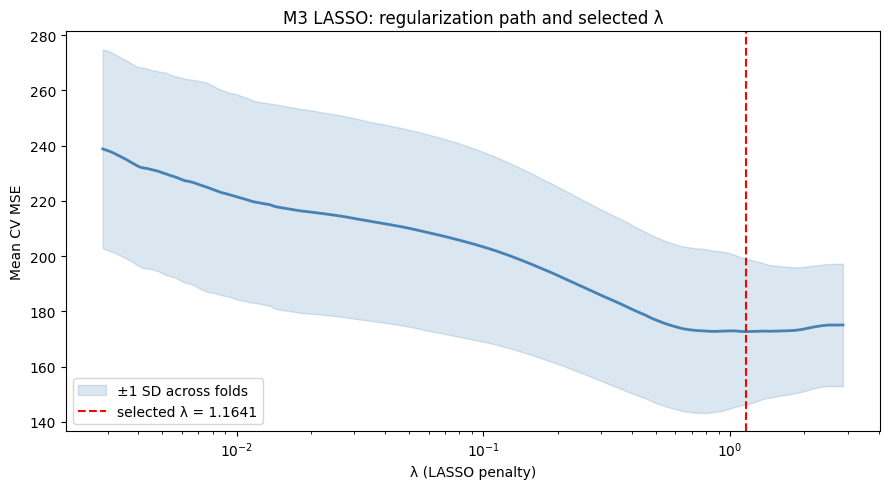

In [57]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(lasso_m3.alphas_, lasso_m3.mse_path_.mean(axis=1), color='steelblue', linewidth=2)
ax.fill_between(
    lasso_m3.alphas_,
    lasso_m3.mse_path_.mean(axis=1) - lasso_m3.mse_path_.std(axis=1),
    lasso_m3.mse_path_.mean(axis=1) + lasso_m3.mse_path_.std(axis=1),
    alpha=0.2, color='steelblue', label='\u00b11 SD across folds'
)
ax.axvline(alpha_m3, color='red', linestyle='--', label=f'selected \u03bb = {alpha_m3:.4f}')
ax.set_xlabel('\u03bb (LASSO penalty)')
ax.set_ylabel('Mean CV MSE')
ax.set_title('M3 LASSO: regularization path and selected \u03bb')
ax.legend()
plt.tight_layout(); plt.show()

### Figure 5: Lightness variance vs year (segmentation hypothesis test)

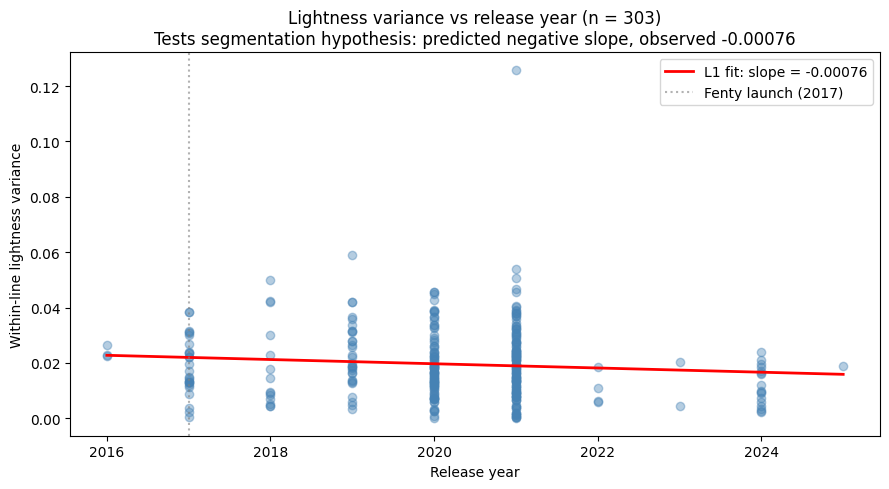

In [58]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(prod_lv['release_year'], prod_lv['lightness_var'], alpha=0.4, color='steelblue')

yr_grid = np.linspace(prod_lv['release_year'].min(), prod_lv['release_year'].max(), 100)
ax.plot(yr_grid, l1.intercept_ + l1.coef_[0] * yr_grid, 'r-', linewidth=2,
        label=f'L1 fit: slope = {l1.coef_[0]:.5f}')

ax.axvline(2017, color='gray', linestyle=':', alpha=0.6, label='Fenty launch (2017)')
ax.set_xlabel('Release year')
ax.set_ylabel('Within-line lightness variance')
ax.set_title(f'Lightness variance vs release year (n = {n_lv})\n'
             f'Tests segmentation hypothesis: predicted negative slope, observed {l1.coef_[0]:.5f}')
ax.legend()
plt.tight_layout(); plt.show()

## 7. Robustness check — brand-baseline centered specification

Sanity check: re-express M2's brand-adjusted year coefficient using a different mathematical parameterization (subtract each brand's pre-2017 mean shade count from each product line). The year coefficient should be roughly equal to M2's brand-adjusted year coefficient (~−1.15 expected). If it is, we've confirmed the brand-dummy approach is doing what we think.

In [59]:
brand_baseline = (
    product_level[product_level['release_year'] <= 2017]
    .groupby('brand')['shade_count'].mean()
    .rename('brand_baseline_2017')
)

prod_centered = product_level.merge(brand_baseline, on='brand')
prod_centered['deviation'] = prod_centered['shade_count'] - prod_centered['brand_baseline_2017']

print(f'product lines retained (have pre-2017 brand baseline): {len(prod_centered)} of {n}')

X_dev = prod_centered[['release_year']].values
y_dev = prod_centered['deviation'].values

m_dev = LinearRegression()
train_rmse_dev, cv_rmse_dev = evaluate_model(m_dev, X_dev, y_dev, kf)

print(f'\nyear coefficient on shade-count deviation: {m_dev.coef_[0]:.4f}')
print(f'compare to M2 brand-adjusted year coefficient: {year_coef_M2:.4f}')
print(f'consistent? {"YES" if abs(m_dev.coef_[0] - year_coef_M2) < 1.0 else "NO - investigate"}')

product lines retained (have pre-2017 brand baseline): 115 of 314

year coefficient on shade-count deviation: -1.1577
compare to M2 brand-adjusted year coefficient: -1.1435
consistent? YES


## 8. Summary — quote-ready numbers for the paper

All the key numbers to drop into the writeup.

In [60]:
print('=' * 70)
print('PAPER-READY NUMBERS')
print('=' * 70)

print('\n--- DATASET ---')
print(f'  n product lines:            {n}')
print(f'  n unique brands:            {n_brands} ({n_brands - 1} dummies w/ drop_first)')
print(f'  release year range:         {int(product_level["release_year"].min())} - {int(product_level["release_year"].max())}')
print(f'  pre-2017 / 2017+ split:     {(product_level["release_year"] < 2017).sum()} / {(product_level["release_year"] >= 2017).sum()}')
print(f'  shade_count median (range): {product_level["shade_count"].median():.0f} ({product_level["shade_count"].min()} - {product_level["shade_count"].max()})')

print('\n--- SHADE COUNT MODELS ---')
print(comparison_sc.to_string(index=False))
print(f'\n  selected model:                {best_sc}')
print(f'  M1 year coefficient:           {m1_sc.coef_[0]:.4f} shades/year')
print(f'  M2 year coefficient (adj):     {year_coef_M2:.4f} shades/year')
print(f'  M3 LASSO selected lambda:      {alpha_m3:.4f}')
print(f'  M3 LASSO non-zero features:    {n_nonzero} of {len(coef_m3)}')
print(f'  M3 year coefficient (scaled):  {coef_m3[0]:.4f}')
print(f'  M4 segmented year coefs (scaled):')
print(f'    pre-2017 slope:              {coef_m4[0]:.4f}')
print(f'    2017 level shift:            {coef_m4[1]:.4f}')
print(f'    post-2017 slope change:      {coef_m4[2]:.4f}')

print('\n--- LIGHTNESS VARIANCE MODELS (segmentation hypothesis) ---')
print(comparison_lv.to_string(index=False))
print(f'\n  L1 year coefficient:           {l1.coef_[0]:.6f}')
print(f'  L2 year coefficient (adj):     {l2.coef_[0]:.6f}')
print(f'  L3 year coefficient (scaled):  {coef_l3[0]:.6f}')
print(f'  L1 train RMSE / CV RMSE:       {results_lv["L1"]["train_rmse"]:.6f} / {results_lv["L1"]["cv_rmse"]:.6f}')
print(f'  -> segmentation hypothesis:    {"NOT supported" if abs(l1.coef_[0]) < 0.001 else "check magnitude"}')

print('\n--- ROBUSTNESS CHECK ---')
print(f'  brand-baseline-centered year coef: {m_dev.coef_[0]:.4f}')
print(f'  vs M2 brand-adjusted year coef:    {year_coef_M2:.4f}')
print(f'  consistent (\u00b11 shade): {"YES" if abs(m_dev.coef_[0] - year_coef_M2) < 1.0 else "NO"}')

PAPER-READY NUMBERS

--- DATASET ---
  n product lines:            314
  n unique brands:            104 (103 dummies w/ drop_first)
  release year range:         2016 - 2025
  pre-2017 / 2017+ split:     3 / 311
  shade_count median (range): 16 (1 - 60)

--- SHADE COUNT MODELS ---
model  n_params  train_rmse   cv_rmse      gap
   M4      22.0   12.227911 13.000499 0.772588
   M3      22.0   12.228454 13.001139 0.772685
   M1       1.0   13.029828 13.075696 0.045868
   M2     104.0    9.419211 14.377777 4.958565

  selected model:                M4
  M1 year coefficient:           -1.3998 shades/year
  M2 year coefficient (adj):     -1.1435 shades/year
  M3 LASSO selected lambda:      1.1641
  M3 LASSO non-zero features:    22 of 104
  M3 year coefficient (scaled):  -1.2377
  M4 segmented year coefs (scaled):
    pre-2017 slope:              -0.0000
    2017 level shift:            -0.0000
    post-2017 slope change:      -1.2419

--- LIGHTNESS VARIANCE MODELS (segmentation hypothesis)

## What to do with these numbers

Drop the relevant subset into:
- **Methods section:** dataset numbers (n, n_brands, year range)
- **Results — model selection:** the comparison tables and Figure 2
- **Results — model estimation:** the year coefficients, the LASSO summary, Figure 3 (coefficient plot)
- **Results — secondary analysis:** the lightness model output and Figure 5
- **Discussion:** the segmentation rejection, the M4 segmented coefficients for the Fenty-break interpretation, the robustness check confirming M2